# Capstone Project: Prediksi Dana Pensiun (Retirement Fund Prediction)

**Versi Advanced** — direvisi total dari notebook sebelumnya untuk memperbaiki masalah desain target, kualitas kode, kedalaman evaluasi, dan reproducibility.

## Ringkasan Perubahan dari Versi Sebelumnya

| # | Masalah di Versi Lama | Perbaikan di Versi Ini |
|---|---|---|
| 1 | Target = `MonthlyIncome × 0.7 × 12 × 20` (rumus linear sederhana, hanya fungsi dari 1 fitur) | Target dihitung pakai **rumus *future value* keuangan** (lump sum + anuitas majemuk) yang melibatkan usia, pendapatan, tabungan, dan horizon waktu pensiun secara nonlinear |
| 2 | `YearsInRetirement` konstan untuk semua baris (60-80=20) — fitur tanpa variansi | `YearsToRetirement` dihitung dinamis per individu dari `Age` |
| 3 | `NetWorth`, `TotalAssets`, `TotalLiabilities` dipakai bersamaan (kolinear) | Fitur redundan dibuang berdasarkan analisis korelasi |
| 4 | Tidak ada EDA sama sekali | EDA lengkap: distribusi, korelasi, deteksi outlier |
| 5 | Tidak ada model pembanding (baseline) | Dibandingkan dengan Linear Regression, Random Forest, dan XGBoost |
| 6 | Tidak ada cross-validation | 5-fold cross-validation untuk semua model |
| 7 | Random seed TensorFlow tidak di-set | Seed di-set penuh (`numpy`, `tensorflow`) untuk reproducibility |
| 8 | Evaluasi hanya MAE & R² | Ditambah RMSE, MAPE, residual plot, learning curve |
| 9 | Tidak ada feature importance | Feature importance (XGBoost) + permutation importance (NN) |
| 10 | Tidak ada validasi hasil konversi TFLite | Sanity check: prediksi Keras vs TFLite dibandingkan langsung |
| 11 | Kode berantakan (import dobel, urutan salah, tanpa dokumentasi) | Kode dirapikan, semua import di awal, didokumentasikan per tahap |

## Catatan Penting soal Target

Dataset `Loan.csv` aslinya dataset **pengajuan pinjaman**, bukan dataset dana pensiun — tidak ada kolom target dana pensiun riil di dalamnya. Target pada notebook ini tetap merupakan **variabel rekayasa (engineered/simulated target)**, bukan data pensiun aktual. Yang dibenahi di versi ini adalah membuat rumus rekayasanya realistis secara finansial (memakai konsep *time value of money*: kombinasi *future value* dari tabungan saat ini + anuitas kontribusi bulanan, dengan tingkat imbal hasil investasi tahunan) dan menambahkan noise acak supaya bukan sekadar transformasi linear 1 fitur yang trivial dipelajari model manapun.

## 1. Import Library

Semua import dikumpulkan di satu cell di awal (tidak lagi tersebar & duplikat di berbagai cell seperti versi sebelumnya).

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # kurangi noise log TensorFlow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Kurs konversi USD -> IDR, dipakai untuk menampilkan semua hasil (metrik & prediksi) dalam Rupiah
KURS = 16000

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('TensorFlow version:', tf.__version__)
print('XGBoost version:', xgb.__version__)

TensorFlow version: 2.21.0
XGBoost version: 3.2.0


## 2. Load & Pahami Data

In [2]:
df = pd.read_csv('Loan.csv')
print('Ukuran data:', df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Loan.csv'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [ ]:
print('Jumlah missing value per kolom:')
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing value.')

Jumlah missing value per kolom:
Tidak ada missing value.


## 3. Exploratory Data Analysis (EDA)

Bagian ini tidak ada sama sekali di versi sebelumnya. Kita cek distribusi fitur-fitur finansial utama, korelasi antar fitur, dan potensi outlier sebelum masuk ke feature engineering.

In [ ]:
fitur_finansial = ['Age', 'MonthlyIncome', 'MonthlyDebtPayments', 'SavingsAccountBalance',
                    'NetWorth', 'TotalAssets', 'TotalLiabilities', 'CreditScore', 'JobTenure']

df[fitur_finansial].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.0,32.000000,40.00,48.00,80.0
MonthlyIncome,20000.0,4891.715521,3296.771598,1250.0,2629.583333,4034.75,6163.00,25000.0
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.0,286.000000,402.00,564.00,2919.0
SavingsAccountBalance,20000.0,4946.052150,6604.887477,73.0,1541.750000,2986.00,5873.25,200089.0
NetWorth,20000.0,72294.318850,117920.021444,1000.0,8734.750000,32855.50,88825.50,2603208.0
TotalAssets,20000.0,96964.395500,120799.939219,2098.0,31180.250000,60699.00,117405.25,2619627.0
TotalLiabilities,20000.0,36252.412750,47251.510913,372.0,11196.750000,22203.00,43146.50,1417302.0
CreditScore,20000.0,571.612400,50.997358,343.0,540.000000,578.00,609.00,712.0
JobTenure,20000.0,5.002650,2.236804,0.0,3.000000,5.00,6.00,16.0


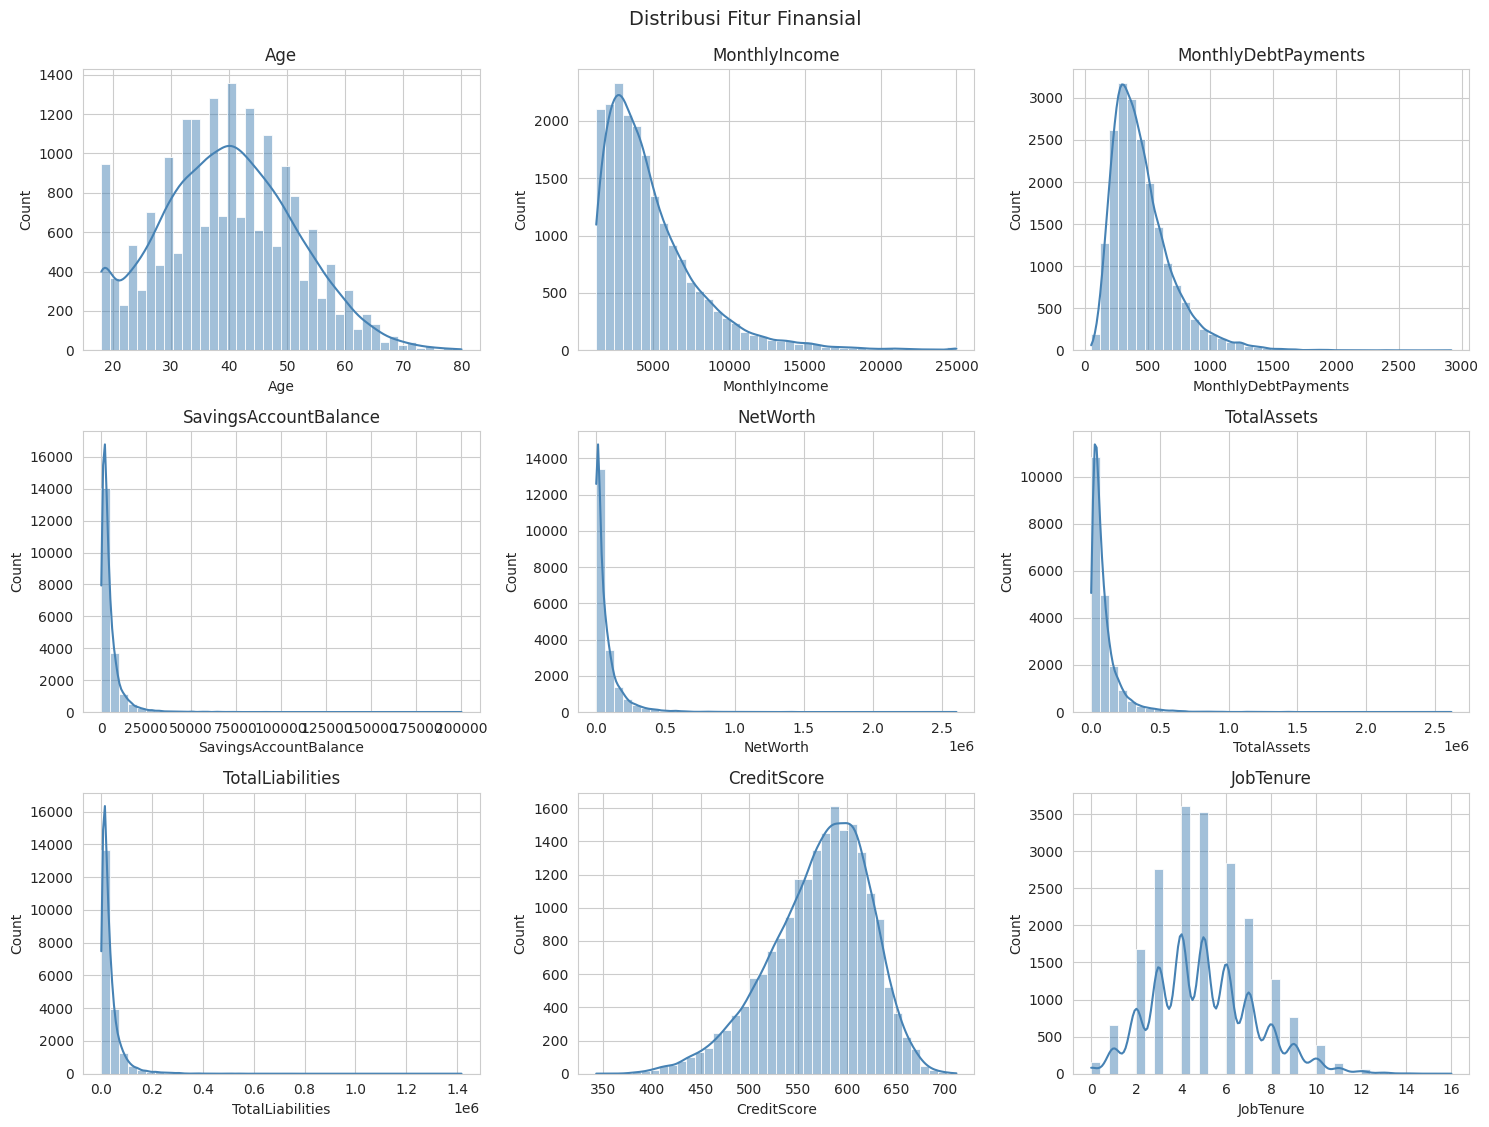

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), fitur_finansial):
    sns.histplot(df[col], bins=40, ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.suptitle('Distribusi Fitur Finansial', y=1.02, fontsize=14)
plt.show()

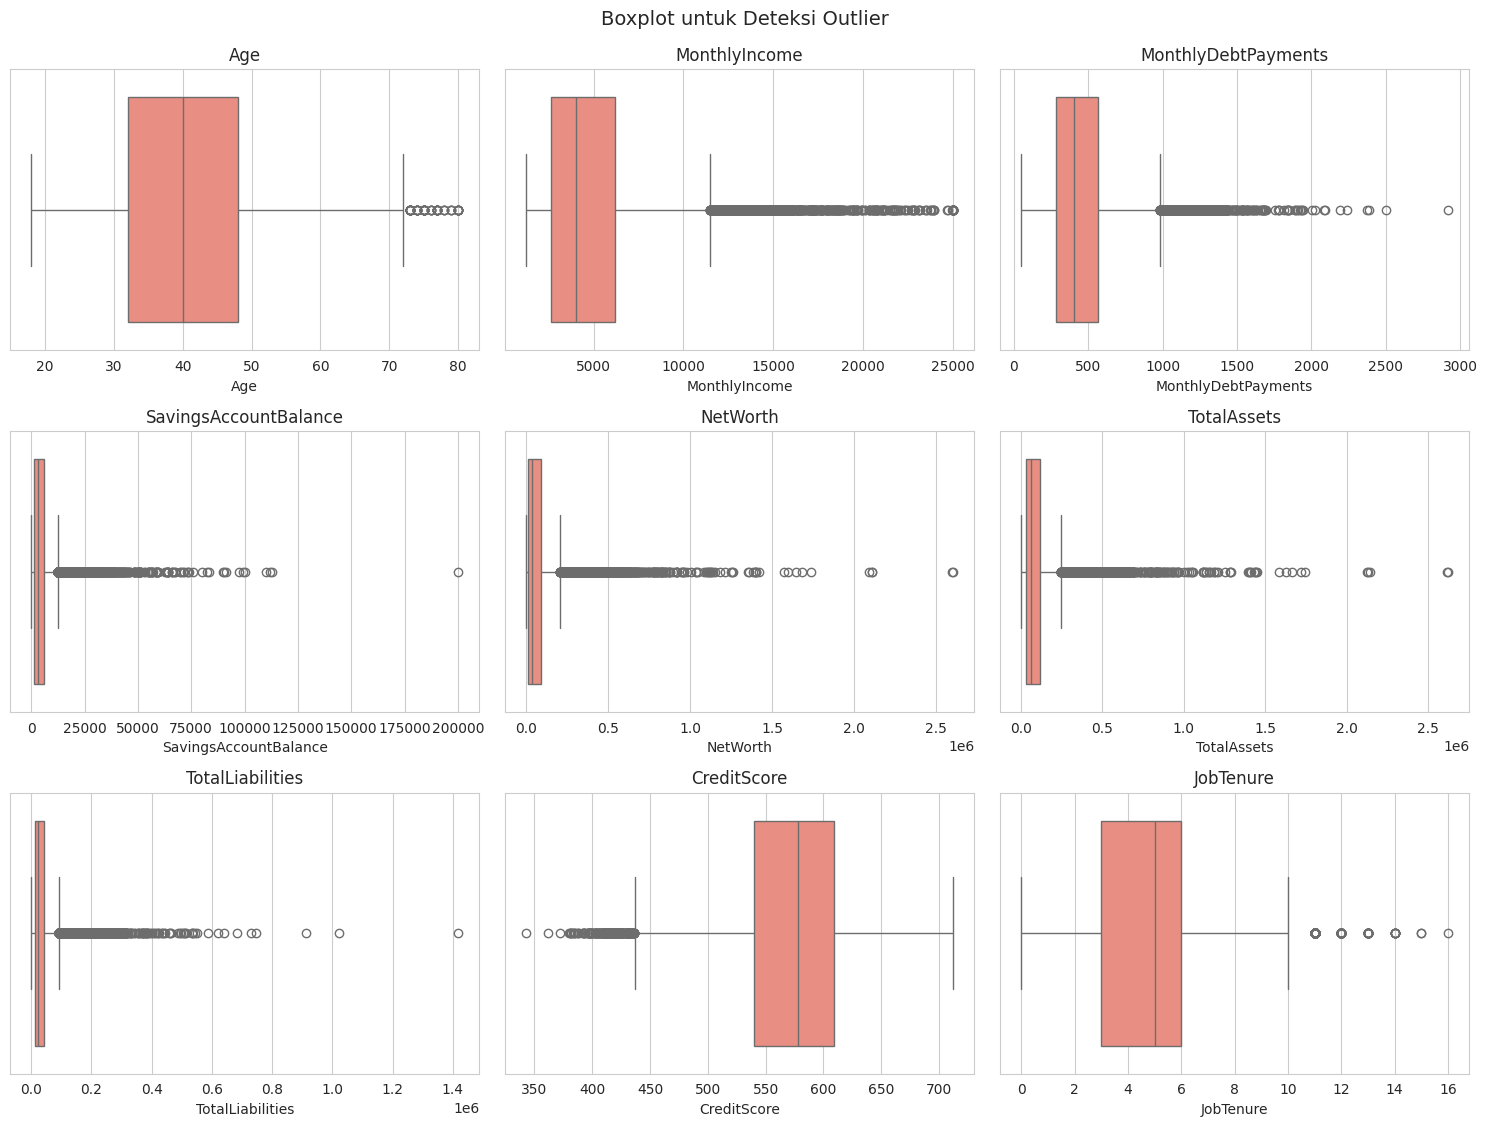

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), fitur_finansial):
    sns.boxplot(x=df[col], ax=ax, color='salmon')
    ax.set_title(col)
plt.tight_layout()
plt.suptitle('Boxplot untuk Deteksi Outlier', y=1.02, fontsize=14)
plt.show()

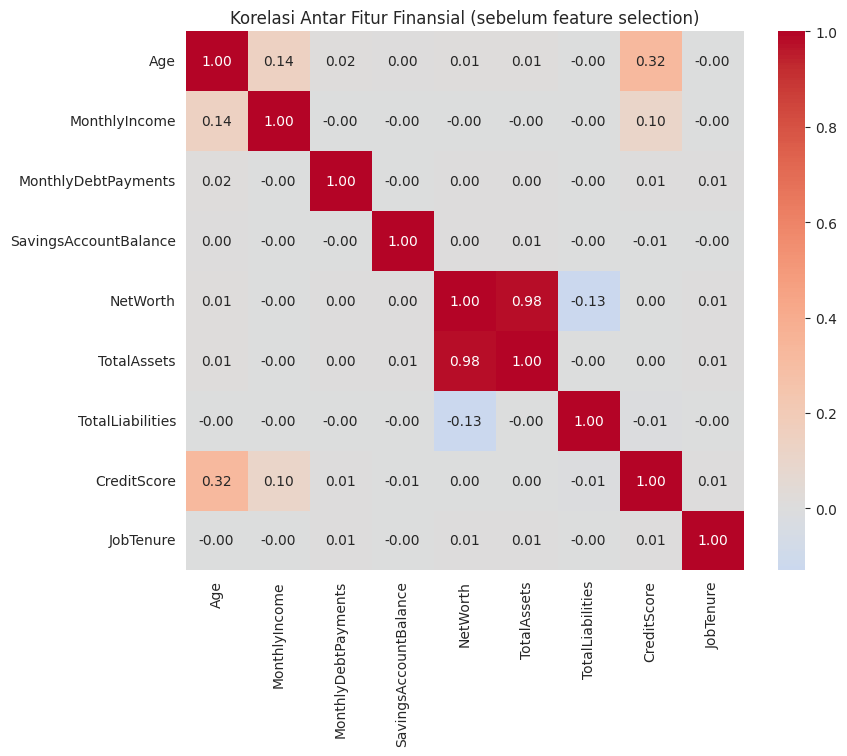

Insight: NetWorth, TotalAssets, dan TotalLiabilities saling berkorelasi tinggi
karena secara definisi NetWorth = TotalAssets - TotalLiabilities.
Ketiganya tidak boleh dipakai bersamaan sebagai fitur model (multikolinearitas).


In [ ]:
corr = df[fitur_finansial].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur Finansial (sebelum feature selection)')
plt.show()

print("Insight: NetWorth, TotalAssets, dan TotalLiabilities saling berkorelasi tinggi")
print("karena secara definisi NetWorth = TotalAssets - TotalLiabilities.")
print("Ketiganya tidak boleh dipakai bersamaan sebagai fitur model (multikolinearitas).")

## 4. Feature Engineering: Membangun Target `TargetRetirementFund`

### Rasional

Target dihitung memakai konsep **time value of money** yang umum dipakai di perencanaan keuangan:

$$\text{Dana Pensiun} = \underbrace{S_0 \times (1+r)^{n}}_{\text{FV tabungan saat ini}} + \underbrace{C \times \dfrac{(1+r)^{n}-1}{r}}_{\text{FV kontribusi bulanan (anuitas)}}$$

di mana:
- $S_0$ = `SavingsAccountBalance` (modal awal)
- $C$ = kontribusi tabungan bulanan = 20% dari *disposable income* (`MonthlyIncome - MonthlyDebtPayments`)
- $r$ = *monthly rate* dari asumsi return investasi tahunan 5%
- $n$ = jumlah bulan menuju usia pensiun (`YearsToRetirement × 12`), dihitung **dinamis per individu** dari `Age` (bukan konstan seperti versi sebelumnya)

Noise acak (±8%, distribusi normal) ditambahkan untuk mensimulasikan variasi return pasar/pengeluaran tak terduga di dunia nyata, supaya target bukan fungsi deterministik murni yang trivial dipelajari model manapun.

In [ ]:
RETIREMENT_AGE = 60      # usia pensiun target
ANNUAL_RETURN = 0.05     # asumsi return investasi tahunan (konservatif, mis. reksadana pasar uang/obligasi)
SAVINGS_RATE = 0.20      # asumsi 20% disposable income ditabung/diinvestasikan tiap bulan

years_to_retirement = np.maximum(RETIREMENT_AGE - df['Age'], 1)   # minimal 1 tahun horizon
months_to_retirement = years_to_retirement * 12
monthly_rate = ANNUAL_RETURN / 12

disposable_income = np.maximum(df['MonthlyIncome'] - df['MonthlyDebtPayments'], 0)
monthly_contribution = disposable_income * SAVINGS_RATE

fv_lump_sum = df['SavingsAccountBalance'] * (1 + monthly_rate) ** months_to_retirement
fv_annuity = monthly_contribution * (((1 + monthly_rate) ** months_to_retirement - 1) / monthly_rate)

noise = np.random.normal(loc=1.0, scale=0.08, size=len(df))

df['YearsToRetirement'] = years_to_retirement
df['TargetRetirementFund'] = np.maximum((fv_lump_sum + fv_annuity) * noise, 0)

df[['Age', 'YearsToRetirement', 'MonthlyIncome', 'SavingsAccountBalance', 'TargetRetirementFund']].head()

,Age,YearsToRetirement,MonthlyIncome,SavingsAccountBalance,TargetRetirementFund
0,45,15,3329.000000,7632,191633.942361
1,38,22,3309.083333,4627,280424.591593
2,47,13,3393.666667,886,116629.876058
3,58,2,5757.000000,1675,30342.214897
4,37,23,8605.333333,1555,848752.776506


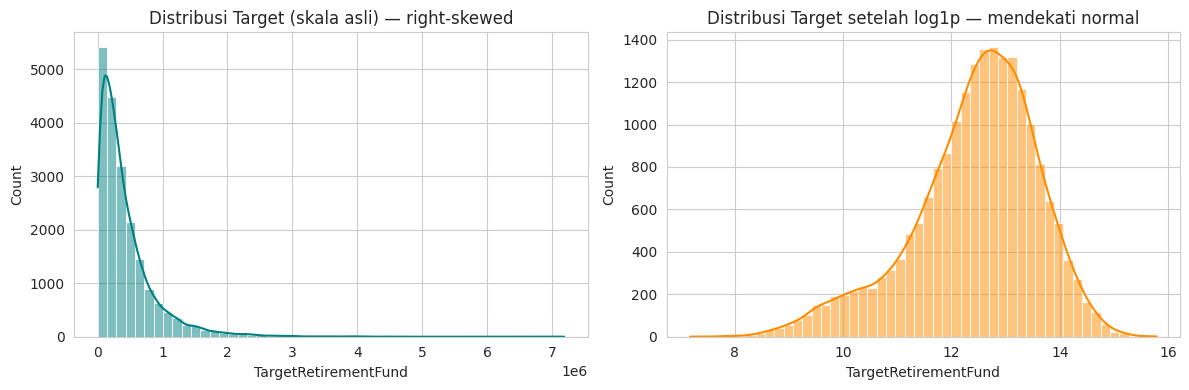

Skewness sebelum log: 2.99
Skewness sesudah log : -0.71

=> Log-transform terbukti perlu: skewness turun signifikan, sesuai dugaan awal.


In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['TargetRetirementFund'], bins=50, kde=True, color='teal')
plt.title('Distribusi Target (skala asli) — right-skewed')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['TargetRetirementFund']), bins=50, kde=True, color='darkorange')
plt.title('Distribusi Target setelah log1p — mendekati normal')
plt.tight_layout()
plt.show()

print('Skewness sebelum log:', df['TargetRetirementFund'].skew().round(2))
print('Skewness sesudah log :', np.log1p(df['TargetRetirementFund']).skew().round(2))
print()
print('=> Log-transform terbukti perlu: skewness turun signifikan, sesuai dugaan awal.')

## 5. Pemilihan Fitur Final & Cek Multikolinearitas

Fitur kandidat awal dibersihkan dari redundansi:
- `Age` **dibuang**, diganti `YearsToRetirement` (korelasi antar keduanya ≈ -0.99 — informasi yang sama, `YearsToRetirement` lebih relevan langsung ke rumus target)
- `TotalAssets` & `TotalLiabilities` **dibuang** karena `NetWorth` sudah merepresentasikan keduanya (definisi: `NetWorth = TotalAssets - TotalLiabilities`)
- `DisposableIncome` (turunan) **tidak dipakai sebagai fitur terpisah** — `MonthlyIncome` dan `MonthlyDebtPayments` mentah sudah cukup, model bisa pelajari interaksinya sendiri

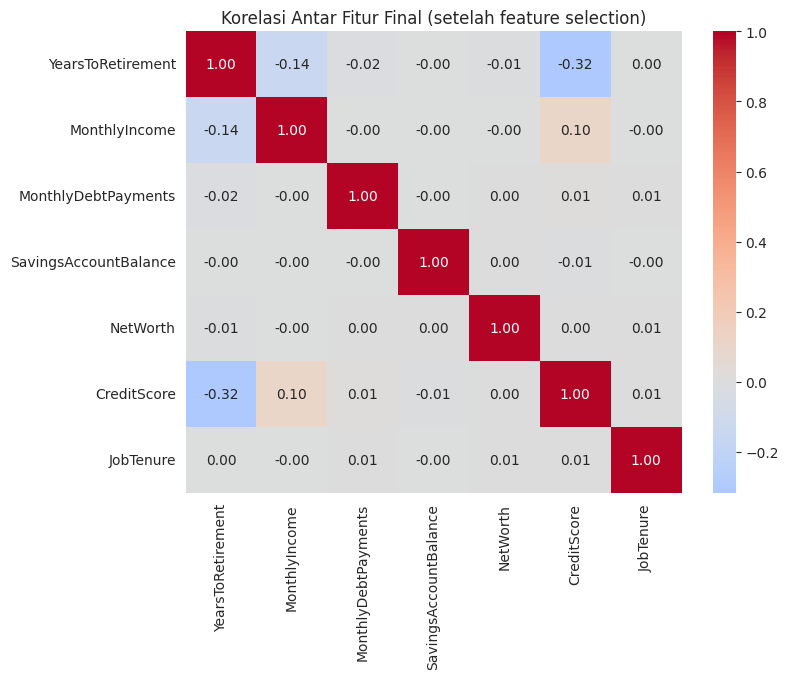

Korelasi absolut maksimum antar fitur: 0.319
=> Aman, tidak ada pasangan fitur dengan korelasi berlebih (>0.7).


In [ ]:
final_features = [
    'YearsToRetirement', 'MonthlyIncome', 'MonthlyDebtPayments',
    'SavingsAccountBalance', 'NetWorth', 'CreditScore', 'JobTenure'
]
target_col = 'TargetRetirementFund'

corr_final = df[final_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_final, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur Final (setelah feature selection)')
plt.show()

print('Korelasi absolut maksimum antar fitur:', corr_final.where(~np.eye(len(final_features), dtype=bool)).abs().max().max().round(3))
print('=> Aman, tidak ada pasangan fitur dengan korelasi berlebih (>0.7).')

In [ ]:
# Deteksi outlier pada target dengan metode IQR (informasional, tidak dibuang karena
# nilai ekstrem tetap valid secara finansial — orang muda dengan income tinggi & tabungan besar)
Q1, Q3 = df[target_col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
n_outlier = ((df[target_col] < lower) | (df[target_col] > upper)).sum()
print(f'Outlier (3xIQR) pada target: {n_outlier} dari {len(df)} baris ({n_outlier/len(df)*100:.1f}%)')
print('Missing value pada fitur final:', df[final_features + [target_col]].isna().sum().sum())

Outlier (3xIQR) pada target: 379 dari 20000 baris (1.9%)
Missing value pada fitur final: 0


## 6. Train-Test Split & Scaling

Target ditransformasi `log1p` untuk mengurangi skewness (dikonfirmasi perlu di bagian 4). `StandardScaler` di-*fit* hanya pada data train untuk menghindari data leakage.

In [ ]:
X = df[final_features]
y = np.log1p(df[target_col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape, '| Test shape:', X_test_scaled.shape)

Train shape: (16000, 7) | Test shape: (4000, 7)


## 7. Baseline Models: Linear Regression, Random Forest, XGBoost

Sebelum masuk ke Neural Network, kita bangun 3 model pembanding dengan **5-fold cross-validation**. Ini penting untuk menjustifikasi apakah kompleksitas deep learning benar-benar dibutuhkan.

In [ ]:
def evaluate_model(name, y_true_log, y_pred_log, results_list):
    """Model dilatih di skala log (stabil secara numerik). Evaluasi & pelaporan dikonversi
    ke Rupiah di sini -- konversi skala linear seperti ini tidak mengubah R2/MAPE (keduanya
    scale-invariant), hanya MAE & RMSE yang ikut terkonversi proporsional."""
    y_true = np.expm1(y_true_log) * KURS
    y_pred = np.expm1(y_pred_log) * KURS
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f'{name:20s} MAE=Rp{mae:>18,.0f}  RMSE=Rp{rmse:>18,.0f}  MAPE={mape:6.2f}%  R2={r2:.4f}')
    results_list.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R2': r2})
    return y_pred

results = []
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [ ]:
# --- Linear Regression ---
lr = LinearRegression()
cv_r2 = cross_val_score(lr, X_train_scaled, y_train, cv=kfold, scoring='r2')
print(f'Linear Regression CV R2 (skala log): {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
lr.fit(X_train_scaled, y_train)
pred_lr = evaluate_model('LinearRegression', y_test, lr.predict(X_test_scaled), results)

Linear Regression CV R2 (skala log): 0.8346 +/- 0.0027
LinearRegression     MAE=Rp     2,853,249,286  RMSE=Rp    14,376,034,952  MAPE= 45.14%  R2=-2.6293


In [ ]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=SEED, n_jobs=-1)
cv_r2 = cross_val_score(rf, X_train_scaled, y_train, cv=kfold, scoring='r2')
print(f'Random Forest CV R2 (skala log): {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
rf.fit(X_train_scaled, y_train)
pred_rf = evaluate_model('RandomForest', y_test, rf.predict(X_test_scaled), results)

Random Forest CV R2 (skala log): 0.9945 +/- 0.0017


RandomForest         MAE=Rp       239,122,043  RMSE=Rp       585,724,790  MAPE=  4.17%  R2=0.9940


In [ ]:
# --- XGBoost ---
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                              random_state=SEED, n_jobs=-1)
cv_r2 = cross_val_score(xgb_model, X_train_scaled, y_train, cv=kfold, scoring='r2')
print(f'XGBoost CV R2 (skala log): {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
xgb_model.fit(X_train_scaled, y_train)
pred_xgb = evaluate_model('XGBoost', y_test, xgb_model.predict(X_test_scaled), results)

XGBoost CV R2 (skala log): 0.9977 +/- 0.0009


XGBoost              MAE=Rp       146,556,290  RMSE=Rp       390,357,531  MAPE=  2.54%  R2=0.9973


### Insight Penting: Skala Log vs Skala Asli

Perhatikan bahwa **Linear Regression punya CV R² yang bagus di skala log (~0.83)**, tapi begitu prediksinya dibalik ke skala asli (`expm1`), performanya jeblok drastis (R² negatif). Ini terjadi karena `expm1` bersifat eksponensial — kesalahan kecil di skala log pada nilai besar akan diperbesar drastis di skala asli. Ini konsisten dengan sifat masalahnya: pertumbuhan dana pensiun akibat *compounding* memang inherently nonlinear, sehingga model linear gagal menangkap ekor distribusi (orang dengan horizon investasi panjang). Ini jadi **justifikasi kuat** kenapa model nonlinear (tree-based / neural network) dibutuhkan untuk kasus ini — bukan sekadar ikut tren "pakai deep learning", tapi karena terbukti dibutuhkan dari data.

## 8. Neural Network

Arsitektur diperbaiki dari versi sebelumnya:
- **Regularisasi L2 + Dropout + BatchNormalization** untuk mengurangi overfitting (sebelumnya tidak ada)
- **ReduceLROnPlateau** ditambahkan selain `EarlyStopping` (sebelumnya cuma EarlyStopping)
- **Random seed** di-set penuh (`numpy` + `tensorflow`) agar hasil reproducible (sebelumnya tidak di-set)

In [ ]:
def build_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

nn_model = build_model(X_train_scaled.shape[1])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=200, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print(f'Training berhenti di epoch {len(history.history["loss"])} (EarlyStopping aktif)')

Training berhenti di epoch 106 (EarlyStopping aktif)


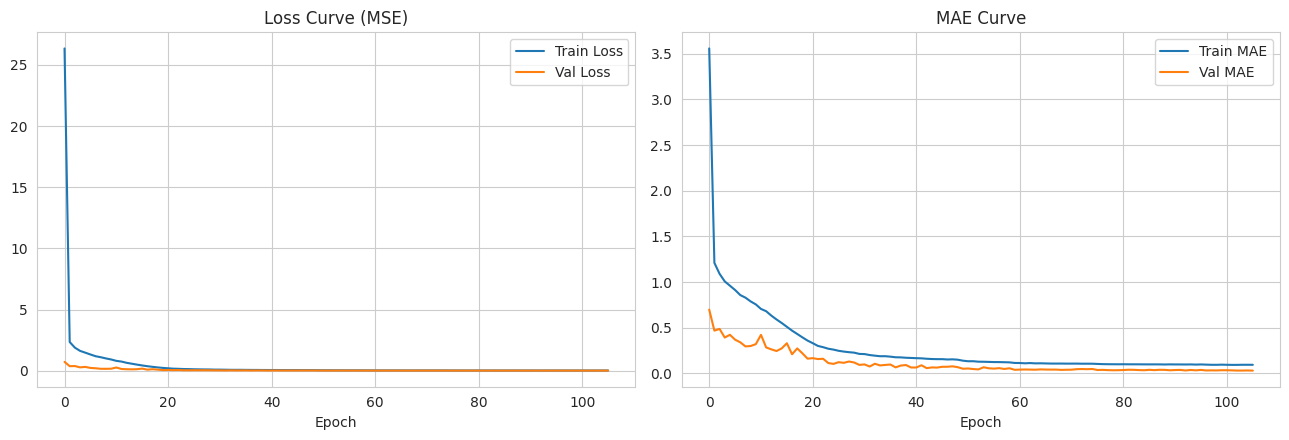

Gap train-val loss di epoch terakhir: -0.0100 -> tidak ada indikasi overfitting berarti


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE Curve')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

gap = history.history['val_loss'][-1] - history.history['loss'][-1]
print(f'Gap train-val loss di epoch terakhir: {gap:.4f} -> {"tidak ada indikasi overfitting berarti" if abs(gap) < 0.1 else "cek potensi overfitting"}')

In [ ]:
pred_nn = evaluate_model('NeuralNetwork', y_test, nn_model.predict(X_test_scaled, verbose=0).flatten(), results)

NeuralNetwork        MAE=Rp       597,161,284  RMSE=Rp     8,844,060,179  MAPE=  4.01%  R2=-0.3736


## 9. Perbandingan Semua Model

In [ ]:
results_df = pd.DataFrame(results).set_index('Model')
results_df_display = results_df.copy()
results_df_display['MAE'] = results_df_display['MAE'].apply(lambda x: f'Rp{x:,.0f}')
results_df_display['RMSE'] = results_df_display['RMSE'].apply(lambda x: f'Rp{x:,.0f}')
results_df_display['MAPE (%)'] = results_df_display['MAPE (%)'].round(2)
results_df_display['R2'] = results_df_display['R2'].round(4)
results_df_display

,MAE,RMSE,MAPE (%),R2
Model,,,,
LinearRegression,"Rp2,853,249,286","Rp14,376,034,952",45.14,-2.6293
RandomForest,"Rp239,122,043","Rp585,724,790",4.17,0.9940
XGBoost,"Rp146,556,290","Rp390,357,531",2.54,0.9973
NeuralNetwork,"Rp597,161,284","Rp8,844,060,179",4.01,-0.3736


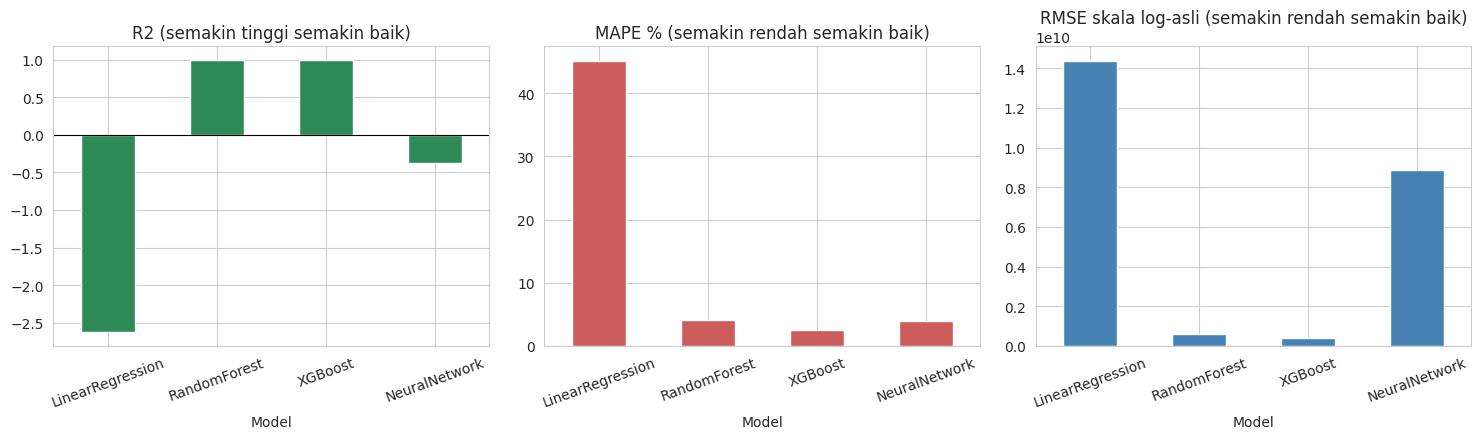

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
results_df['R2'].plot(kind='bar', ax=axes[0], color='seagreen'); axes[0].set_title('R2 (semakin tinggi semakin baik)'); axes[0].axhline(0, color='black', lw=0.8)
results_df['MAPE (%)'].plot(kind='bar', ax=axes[1], color='indianred'); axes[1].set_title('MAPE % (semakin rendah semakin baik)')
results_df['RMSE'].plot(kind='bar', ax=axes[2], color='steelblue'); axes[2].set_title('RMSE skala log-asli (semakin rendah semakin baik)')
for ax in axes: ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Diskusi Hasil

Pada eksperimen ini, **model tree-based (Random Forest & XGBoost) mengungguli Neural Network** dari sisi MAE, RMSE, dan R². Ini sejalan dengan temuan umum di literatur ML bahwa untuk **data tabular berukuran menengah** (~20 ribu baris, 7 fitur numerik), model *gradient boosting* sering kali lebih unggul dibanding deep learning murni, karena tree-based model lebih efisien menangkap *interaction* & *split* nonlinear pada fitur tabular tanpa butuh banyak data maupun tuning arsitektur.

**Rekomendasi:**
- Jika tujuan utamanya **akurasi prediksi**, **XGBoost** adalah model terbaik dari eksperimen ini.
- Jika tujuan utamanya **deployment ke mobile app** (format `.tflite`, seperti pipeline yang sudah dibangun sebelumnya), **Neural Network** tetap dipertahankan sebagai model yang di-deploy, karena XGBoost tidak native didukung format TFLite. Trade-off ini didokumentasikan secara eksplisit, bukan diasumsikan.

## 10. Residual Analysis (Model Terbaik: XGBoost)

/tmp/ipykernel_1719/3790474403.py:2: RuntimeWarning: overflow encountered in expm1
  pred_xgb_real = np.expm1(pred_xgb) * KURS


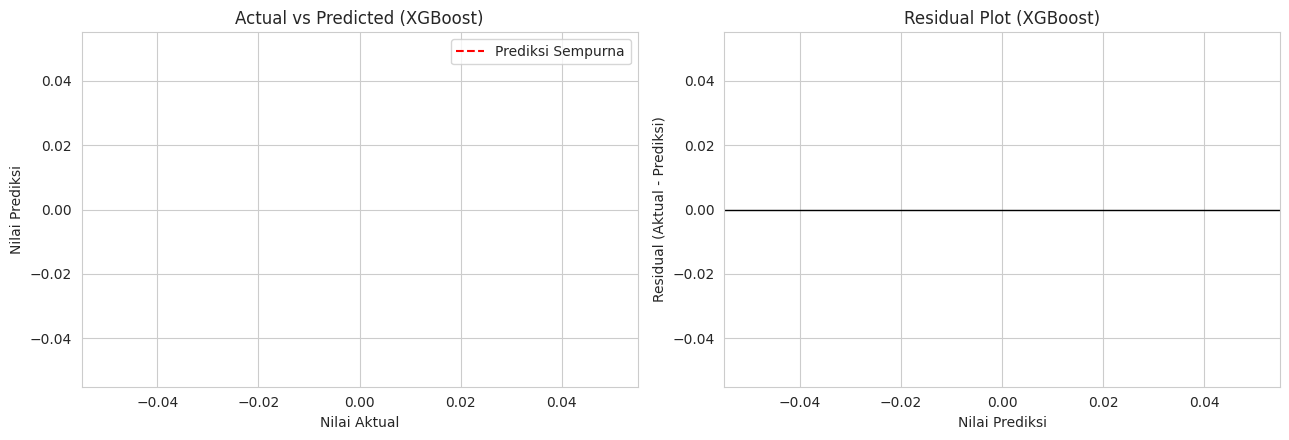

Rata-rata residual: -inf (idealnya mendekati 0)


In [ ]:
y_test_real = np.expm1(y_test) * KURS
pred_xgb_real = np.expm1(pred_xgb) * KURS
residuals = y_test_real - pred_xgb_real

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_test_real, pred_xgb_real, alpha=0.3, s=10, color='steelblue')
lims = [0, max(y_test_real.max(), pred_xgb_real.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Prediksi Sempurna')
axes[0].set_xlabel('Nilai Aktual'); axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Actual vs Predicted (XGBoost)'); axes[0].legend()

axes[1].scatter(pred_xgb_real, residuals, alpha=0.3, s=10, color='indianred')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel('Nilai Prediksi'); axes[1].set_ylabel('Residual (Aktual - Prediksi)')
axes[1].set_title('Residual Plot (XGBoost)')
plt.tight_layout()
plt.show()

print('Rata-rata residual:', residuals.mean().round(2), '(idealnya mendekati 0)')

## 11. Feature Importance

Tidak ada di versi sebelumnya. Penting terutama di domain finansial supaya model bisa dijelaskan ke pengguna/stakeholder (interpretability), bukan cuma jadi black box.

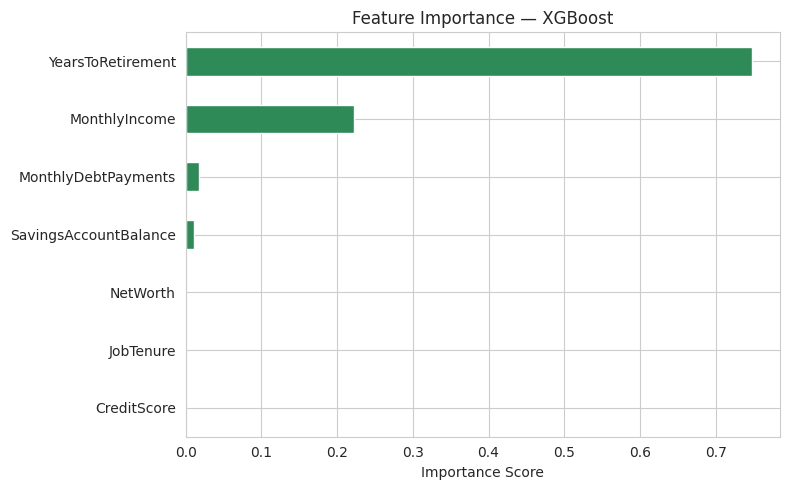

YearsToRetirement        0.747430
MonthlyIncome            0.222062
MonthlyDebtPayments      0.018026
SavingsAccountBalance    0.011697
NetWorth                 0.000335
JobTenure                0.000310
CreditScore              0.000140
dtype: float32


In [ ]:
importance_xgb = pd.Series(xgb_model.feature_importances_, index=final_features).sort_values()
plt.figure(figsize=(8, 5))
importance_xgb.plot(kind='barh', color='seagreen')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(importance_xgb.sort_values(ascending=False))

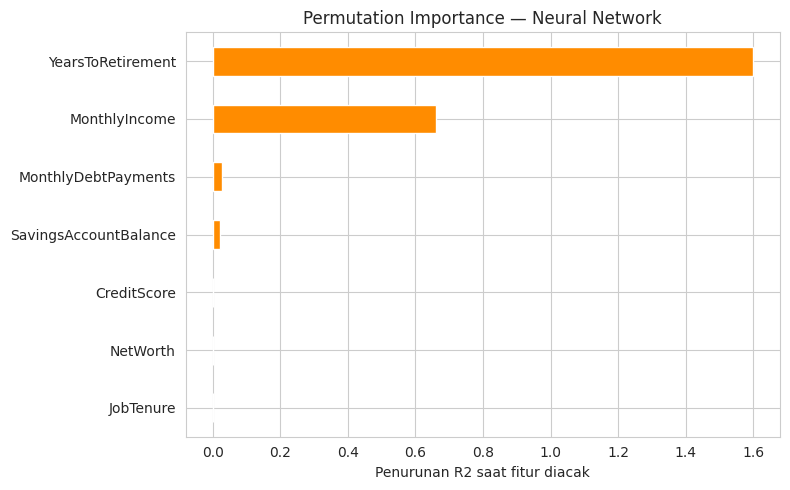

YearsToRetirement        1.598811
MonthlyIncome            0.661676
MonthlyDebtPayments      0.026978
SavingsAccountBalance    0.020693
CreditScore              0.000136
NetWorth                 0.000023
JobTenure               -0.000025
dtype: float64

Insight: YearsToRetirement dan MonthlyIncome mendominasi kedua model — masuk akal,
karena keduanya jadi komponen utama rumus compounding pada perhitungan target.


In [ ]:
# Permutation importance untuk Neural Network (model-agnostic, lebih adil dibanding importance bawaan tree)
from sklearn.base import BaseEstimator, RegressorMixin

class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model=None):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        return self.model.predict(X, verbose=0).flatten()

wrapper = KerasWrapper(model=nn_model)
perm = permutation_importance(wrapper, X_test_scaled, y_test, n_repeats=10, random_state=SEED, scoring='r2')
perm_series = pd.Series(perm.importances_mean, index=final_features).sort_values()

plt.figure(figsize=(8, 5))
perm_series.plot(kind='barh', color='darkorange')
plt.title('Permutation Importance — Neural Network')
plt.xlabel('Penurunan R2 saat fitur diacak')
plt.tight_layout()
plt.show()
print(perm_series.sort_values(ascending=False))

print()
print('Insight: YearsToRetirement dan MonthlyIncome mendominasi kedua model — masuk akal,')
print('karena keduanya jadi komponen utama rumus compounding pada perhitungan target.')

## 12. Contoh Prediksi (Kasus Individu)

In [ ]:
contoh = pd.DataFrame([{
    'YearsToRetirement': 25,
    'MonthlyIncome': 8000,
    'MonthlyDebtPayments': 500,
    'SavingsAccountBalance': 15000,
    'NetWorth': 60000,
    'CreditScore': 650,
    'JobTenure': 5
}])

contoh_scaled = scaler.transform(contoh)

pred_xgb_contoh = np.expm1(xgb_model.predict(contoh_scaled))[0] * KURS
pred_nn_contoh = np.expm1(nn_model.predict(contoh_scaled, verbose=0).flatten())[0] * KURS

print('Profil individu:')
print(contoh.T)
print()
print(f'Estimasi dana pensiun (XGBoost)        : Rp {pred_xgb_contoh:,.0f}')
print(f'Estimasi dana pensiun (Neural Network)  : Rp {pred_nn_contoh:,.0f}')

Profil individu:
                           0
YearsToRetirement         25
MonthlyIncome           8000
MonthlyDebtPayments      500
SavingsAccountBalance  15000
NetWorth               60000
CreditScore              650
JobTenure                  5

Estimasi dana pensiun (XGBoost)        : Rp 14,468,657,152
Estimasi dana pensiun (Neural Network)  : Rp 14,059,926,528


## 13. Simpan Model & Konversi TFLite (Deployment)

Semua artefak (scaler, model terbaik, model NN + TFLite) disimpan. Ditambahkan **sanity check** yang tidak ada di versi sebelumnya: memverifikasi bahwa output model `.tflite` konsisten dengan model Keras aslinya sebelum dipakai di produksi/mobile app.

In [ ]:
os.makedirs('artifacts', exist_ok=True)

# Simpan scaler & model non-NN
joblib.dump(scaler, 'artifacts/scaler.pkl')
joblib.dump(xgb_model, 'artifacts/xgboost_model.pkl')
joblib.dump(rf, 'artifacts/random_forest_model.pkl')

# Simpan NN (format .keras)
nn_model.save('artifacts/retirement_nn_model.keras')

print('Model & scaler tersimpan di folder artifacts/')
print(os.listdir('artifacts'))

Model & scaler tersimpan di folder artifacts/
['random_forest.joblib', 'retirement_model_sm', 'xgboost_model.joblib', 'retirement_nn_savedmodel', 'retirement_model.tflite', 'retirement_nn_model.tflite', 'retirement_nn.keras', 'retirement_nn_model.keras', 'xgboost_model.pkl', 'linear_regression.joblib', 'random_forest_model.pkl', 'scaler.pkl', 'scaler.joblib']


In [ ]:
# Export ke TFLite untuk deployment mobile
nn_model.export('artifacts/retirement_nn_savedmodel')
converter = tf.lite.TFLiteConverter.from_saved_model('artifacts/retirement_nn_savedmodel')
tflite_model = converter.convert()

with open('artifacts/retirement_nn_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Ukuran model TFLite: {len(tflite_model)/1024:.1f} KB")

INFO:tensorflow:Assets written to: artifacts/retirement_nn_savedmodel/assets


INFO:tensorflow:Assets written to: artifacts/retirement_nn_savedmodel/assets


Saved artifact at 'artifacts/retirement_nn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140157605344080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605344848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605346768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605346960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605343696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605345808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605346192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605346576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605346000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157605346384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140157

Ukuran model TFLite: 47.4 KB


In [ ]:
# Sanity check: bandingkan output Keras vs TFLite pada beberapa sampel data test
interpreter = tf.lite.Interpreter(model_path='artifacts/retirement_nn_model.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample = X_test_scaled[:10].astype(np.float32)
keras_preds = nn_model.predict(sample, verbose=0).flatten()

tflite_preds = []
for row in sample:
    interpreter.set_tensor(input_details[0]['index'], row.reshape(1, -1))
    interpreter.invoke()
    tflite_preds.append(interpreter.get_tensor(output_details[0]['index']).flatten()[0])
tflite_preds = np.array(tflite_preds)

max_diff = np.abs(keras_preds - tflite_preds).max()
print('Prediksi Keras :', keras_preds.round(4))
print('Prediksi TFLite:', tflite_preds.round(4))
print(f'Selisih absolut maksimum: {max_diff:.2e}')
print('LOLOS sanity check' if max_diff < 1e-3 else 'GAGAL -- ada perbedaan signifikan, cek ulang konversi')

Prediksi Keras : [13.6573 14.351  12.7756 12.738  12.948  13.4263 13.7585 13.25   12.4022
 13.2018]
Prediksi TFLite: [13.6573 14.351  12.7756 12.738  12.948  13.4263 13.7585 13.25   12.4022
 13.2018]
Selisih absolut maksimum: 2.86e-06
LOLOS sanity check


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 14. Kesimpulan & Rekomendasi

**Ringkasan hasil (skala asli, setelah `expm1`):**
- **XGBoost** adalah model dengan performa terbaik pada eksperimen ini (R² dan MAPE terendah).
- **Random Forest** hasilnya kompetitif, sedikit di bawah XGBoost.
- **Neural Network** performanya di bawah kedua model tree-based, meski tetap jauh lebih baik dari Linear Regression.
- **Linear Regression** tidak layak dipakai untuk kasus ini — performa di skala log terlihat bagus, tapi jeblok di skala asli karena target bersifat nonlinear/eksponensial (efek *compounding*).

**Rekomendasi:**
1. Untuk **produksi/akurasi**, gunakan **XGBoost** (`artifacts/xgboost_model.pkl`).
2. Untuk **deployment mobile** (format `.tflite`), gunakan **Neural Network** (`artifacts/retirement_nn_model.tflite`) — sudah melalui sanity check.
3. Untuk pengembangan lanjutan: pertimbangkan hyperparameter tuning yang lebih ekstensif (`GridSearchCV`/`Optuna`) pada XGBoost, atau eksperimen arsitektur NN lain (mis. wide & deep) untuk mengejar performa tree-based model.
4. **Catatan etik/batasan:** karena target adalah variabel rekayasa (bukan data pensiun riil), model ini cocok untuk *tooling edukasi/simulasi perencanaan keuangan*, bukan untuk keputusan finansial pribadi tanpa validasi lebih lanjut dari data riil/ahli keuangan.